In [3]:
import pandas as pd

# exibir todas as colunas
pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
df = pd.read_csv(url)

display(df.head())

,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,descricao,descricao_area_residencial,descricao_companhia_domiciliar,descricao_estado_civil,descricao_historico,descricao_imovel,descricao_mae_escolaridade,descricao_pai_escolaridade,descricao_raca,descricao_responsavel_escolaridade,descricao_responsavel_financeiro,descricao_trabalho,id,idade,pessoa_fisica__sexo,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,sigla,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,conceito,conceito_freq,acompanhamento
0,68.0,0,100.0,66.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Branca,Ensino fundamental incompleto,Mãe,Não informado,457884597605,15,F,False,0,2,LAJ,1,1,0,1,B,A,0
1,73.0,1,100.0,36.0,1,91.0,False,Cancelado,Urbana,Mãe,Solteiro(a),Técnico de Nível Médio em Meio Ambiente,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Parda,Ensino fundamental incompleto,Mãe,Não informado,458436647741,17,M,False,1,2,SPP,2,1,1,0,R,R,0
2,61.0,0,100.0,60.0,0,100.0,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino médio completo,Ensino médio completo,Parda,Ensino médio completo,Mãe,Não informado,464029640533,15,M,True,0,5,CANG,2,2,0,1,B,A,0
3,NaN,-1,NaN,NaN,-1,NaN,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nível Médio em Mecânica,Alugado,Alfabetizado,Não estudou,Parda,Ensino fundamental incompleto,Mãe,Não está trabalhando,556372572373,16,F,False,1,5,MO,3,2,0,1,S,S,0
4,69.0,0,100.0,63.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Preta,Ensino fundamental incompleto,Mãe,Não está trabalhando,457614148801,15,F,False,0,3,PAR,1,1,0,1,R,A,2


In [4]:
df_sel = df[['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'descricao_responsavel_escolaridade', 'idade', 'descricao_raca', 'pessoa_fisica__sexo', 'classe']]
df_sel

,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,classe
0,68.0,66.0,Ensino fundamental incompleto,15,Branca,F,1
1,73.0,36.0,Ensino fundamental incompleto,17,Parda,M,0
2,61.0,60.0,Ensino médio completo,15,Parda,M,1
3,NaN,NaN,Ensino fundamental incompleto,16,Parda,F,1
4,69.0,63.0,Ensino fundamental incompleto,15,Preta,F,1
...,...,...,...,...,...,...,...
8903,29.0,11.0,Ensino fundamental incompleto,15,Amarela,M,0
8904,86.0,71.0,Ensino fundamental incompleto,15,Branca,F,1
8905,61.0,67.0,Ensino fundamental incompleto,15,Parda,F,1
8906,93.0,78.0,Ensino fundamental incompleto,14,Parda,F,1


In [5]:
# Inverter os valores da classe (0 -> 1, 1 -> 0) - igual ao MODULO_08
df_sel['classe'] = 1 - df_sel['classe']

print("Classe invertida!")
print(f"Distribuição da classe (invertida):\n{df_sel['classe'].value_counts()}")

Classe invertida!
Distribuição da classe (invertida):
classe
0    8352
1     556
Name: count, dtype: int64


/var/folders/qq/pvvjcqys15v14km9lr6xcy1w0000gn/T/ipykernel_34159/3781192298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['classe'] = 1 - df_sel['classe']


In [24]:
# Instalação do AutoGluon (descomente se necessário)
# %pip install autogluon -q

## AutoGluon AutoML - Setup e Configuração

O AutoGluon automatiza todo o pipeline de Machine Learning: pré-processamento, seleção de features, comparação de modelos, ensembling e stacking de forma automática. É desenvolvido pela AWS e é conhecido por obter excelentes resultados com configuração mínima.

In [7]:
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularDataset, TabularPredictor

# Dividir os dados em treino e teste (80/20)
train_data, test_data = train_test_split(df_sel, test_size=0.2, random_state=42, stratify=df_sel['classe'])

# Converter para TabularDataset
train_data = TabularDataset(train_data)
test_data = TabularDataset(test_data)

print(f"Dados de treino: {len(train_data)} amostras")
print(f"Dados de teste: {len(test_data)} amostras")
print(f"\nDistribuição da classe no treino:\n{train_data['classe'].value_counts()}")
print(f"\nDistribuição da classe no teste:\n{test_data['classe'].value_counts()}")

Dados de treino: 7126 amostras
Dados de teste: 1782 amostras

Distribuição da classe no treino:
classe
0    6681
1     445
Name: count, dtype: int64

Distribuição da classe no teste:
classe
0    1671
1     111
Name: count, dtype: int64


## Treinamento Automático de Modelos

O AutoGluon treina automaticamente diversos algoritmos (LightGBM, CatBoost, XGBoost, Random Forest, Neural Networks, etc.) e cria ensembles para obter o melhor desempenho.

In [8]:
# Criar o predictor e treinar os modelos
# O AutoGluon automaticamente:
# - Detecta o tipo de problema (classificação binária)
# - Aplica pré-processamento apropriado
# - Treina múltiplos modelos
# - Cria ensembles e stacking

predictor = TabularPredictor(
    label='classe',
    eval_metric='roc_auc',  # Usar AUC como métrica de avaliação
    path='AutogluonModels',  # Diretório para salvar os modelos
    verbosity=2
)

# Treinar com presets 'medium_quality' para balancear tempo e qualidade
# Opções: 'best_quality', 'high_quality', 'good_quality', 'medium_quality'
predictor.fit(
    train_data=train_data,
    time_limit=300,  # Limite de 5 minutos para treinamento
    presets='medium_quality',
    num_bag_folds=5,  # 5-fold bagging
    num_stack_levels=1  # 1 nível de stacking
)

print("\nTreinamento concluído!")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.11
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:40 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T6041
CPU Count:          14
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       21.77 GB / 48.00 GB (45.3%)
Disk Space Avail:   172.22 GB / 460.43 GB (37.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/Users/tmedeirosb/Desktop/DEV/TSI/tsi-ad-2025/AutogluonModels"
Train Data Rows:    7126
Train Data Columns: 6
Label Column:       classe
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-valu


Treinamento concluído!


## Comparação e Ranking dos Modelos Treinados

Visualizar o leaderboard com todos os modelos treinados e suas métricas.

In [10]:
# Obter o leaderboard com todos os modelos
leaderboard = predictor.leaderboard(test_data, silent=True)
print("="*70)
print("LEADERBOARD DOS MODELOS TREINADOS")
print("="*70)
display(leaderboard)

# Melhor modelo
print(f"\n🏆 Melhor modelo: {predictor.model_best}")

LEADERBOARD DOS MODELOS TREINADOS


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM_BAG_L2,0.900896,0.876450,roc_auc,0.321272,0.552931,24.461465,0.008386,0.011550,1.500405,2,True,14
1,CatBoost_BAG_L1,0.900429,0.880751,roc_auc,0.004805,0.005040,2.620847,0.004805,0.005040,2.620847,1,True,5
2,CatBoost_BAG_L2,0.900300,0.882908,roc_auc,0.317814,0.546495,25.155815,0.004928,0.005114,2.194755,2,True,17
3,WeightedEnsemble_L3,0.899917,0.898931,roc_auc,0.389909,0.676013,25.873132,0.000732,0.000609,0.216170,3,True,24
4,WeightedEnsemble_L2,0.899103,0.890154,roc_auc,0.121351,0.102245,18.547178,0.000733,0.000747,0.142174,2,True,12
5,LightGBMXT_BAG_L2,0.896898,0.887298,roc_auc,0.323233,0.559453,24.578701,0.010347,0.018072,1.617640,2,True,13
6,XGBoost_BAG_L2,0.895871,0.880209,roc_auc,0.336376,0.556961,23.757555,0.023490,0.015580,0.796495,2,True,21
7,NeuralNetTorch_BAG_L2,0.894887,0.874445,roc_auc,0.359267,0.580832,27.320161,0.046381,0.039452,4.359101,2,True,22
8,ExtraTreesEntr_BAG_L2,0.892636,0.887198,roc_auc,0.353291,0.641624,23.212521,0.040405,0.100243,0.251461,2,True,19
9,LightGBM_BAG_L1,0.891862,0.873202,roc_auc,0.010972,0.010488,1.335043,0.010972,0.010488,1.335043,1,True,2



🏆 Melhor modelo: WeightedEnsemble_L3


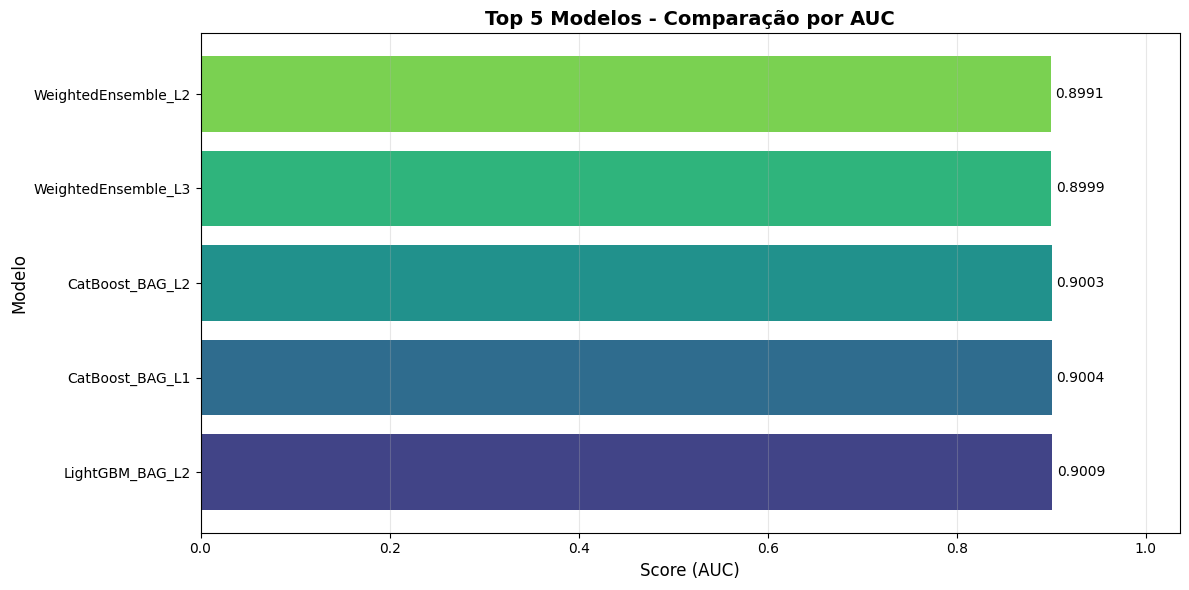

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Gráfico de barras comparando os top 5 modelos por AUC (score_test)
top_models = leaderboard.head(5)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_models)))
bars = ax.barh(top_models['model'], top_models['score_test'], color=colors)

# Adicionar valores nas barras
for bar, score in zip(bars, top_models['score_test']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=10)

ax.set_xlabel('Score (AUC)', fontsize=12)
ax.set_ylabel('Modelo', fontsize=12)
ax.set_title('Top 5 Modelos - Comparação por AUC', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top_models['score_test']) * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Avaliação do Melhor Modelo no Holdout

Avaliar o desempenho do melhor modelo no conjunto de teste.

In [12]:
# Fazer predições no conjunto de teste
y_pred = predictor.predict(test_data)
y_pred_proba = predictor.predict_proba(test_data)
y_true = test_data['classe']

print("="*70)
print("AVALIAÇÃO DO MELHOR MODELO NO HOLDOUT")
print("="*70)

# Avaliar o modelo
evaluation = predictor.evaluate(test_data)
print("\nMétricas de avaliação:")
for metric, value in evaluation.items():
    print(f"  {metric}: {value:.4f}")

# Mostrar algumas predições
results_df = test_data.copy()
results_df['predicao'] = y_pred
results_df['prob_classe_1'] = y_pred_proba[1]
print("\nPrimeiras 10 predições:")
display(results_df[['classe', 'predicao', 'prob_classe_1']].head(10))

AVALIAÇÃO DO MELHOR MODELO NO HOLDOUT

Métricas de avaliação:
  roc_auc: 0.8999
  accuracy: 0.9506
  balanced_accuracy: 0.7003
  mcc: 0.5019
  f1: 0.5111
  precision: 0.6667
  recall: 0.4144

Primeiras 10 predições:


,classe,predicao,prob_classe_1
1948,0,0,0.120587
7460,0,0,0.003903
8378,0,0,0.017953
4228,0,0,0.020640
8513,0,0,0.422327
1778,0,0,0.107695
3416,0,0,0.014013
6069,0,0,0.007980
710,0,0,0.009898
6376,1,0,0.284235


## Visualização - Matriz de Confusão e Curva ROC

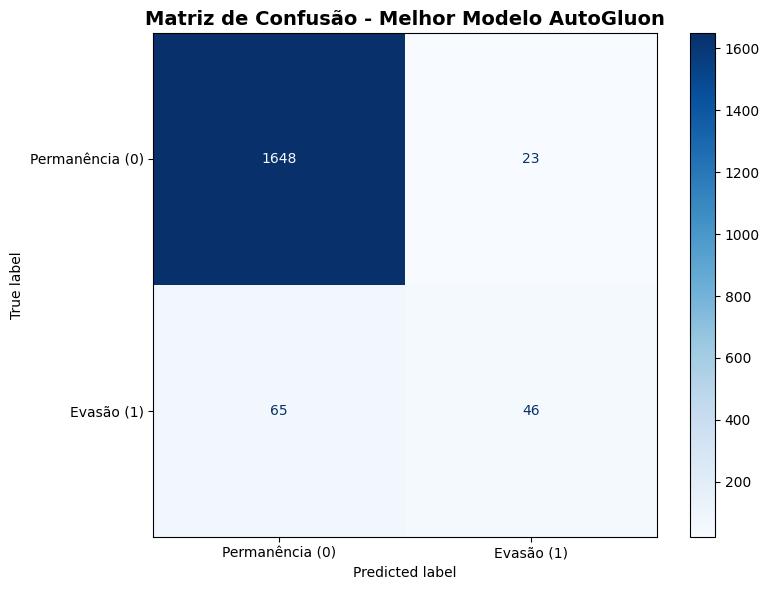


Verdadeiros Negativos (TN): 1648
Falsos Positivos (FP): 23
Falsos Negativos (FN): 65
Verdadeiros Positivos (TP): 46


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permanência (0)', 'Evasão (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusão - Melhor Modelo AutoGluon', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Métricas derivadas da matriz de confusão
tn, fp, fn, tp = cm.ravel()
print(f"\nVerdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")

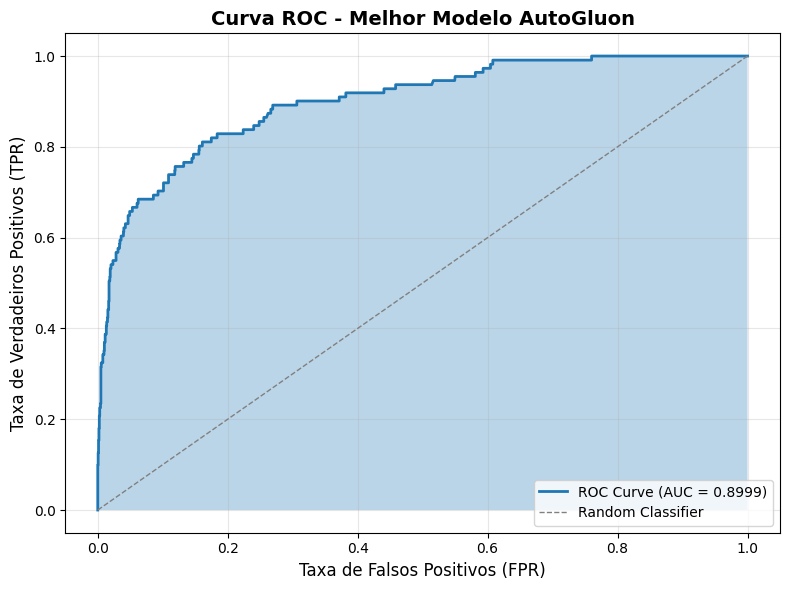

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba[1])
auc_score = roc_auc_score(y_true, y_pred_proba[1])

ax.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3)

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - Melhor Modelo AutoGluon', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score

# Relatório de Classificação Completo
print("="*70)
print("RELATÓRIO DE CLASSIFICAÇÃO COMPLETO")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['Permanência (0)', 'Evasão (1)']))

# Métricas resumidas
print("\nMétricas Resumidas:")
print("-" * 50)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"AUC-ROC:  {auc_score:.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:   {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")

# G-Mean
from math import sqrt
gmean = sqrt(recall_score(y_true, y_pred) * recall_score(y_true, y_pred, pos_label=0))
print(f"G-Mean:   {gmean:.4f}")

RELATÓRIO DE CLASSIFICAÇÃO COMPLETO
                 precision    recall  f1-score   support

Permanência (0)       0.96      0.99      0.97      1671
     Evasão (1)       0.67      0.41      0.51       111

       accuracy                           0.95      1782
      macro avg       0.81      0.70      0.74      1782
   weighted avg       0.94      0.95      0.95      1782


Métricas Resumidas:
--------------------------------------------------
Accuracy: 0.9506
AUC-ROC:  0.8999
Precision: 0.6667
Recall:   0.4144
F1-Score: 0.5111
G-Mean:   0.6393


## Interpretabilidade do Melhor Modelo (Feature Importance)

In [16]:
# Feature Importance usando permutation importance
# Calcula a importância de cada feature baseado no impacto na performance quando os valores são permutados

feature_importance = predictor.feature_importance(test_data)
print("="*70)
print("FEATURE IMPORTANCE (Permutation Importance)")
print("="*70)
display(feature_importance)

Computing feature importance via permutation shuffling for 6 features using 1782 rows with 5 shuffle sets...
	13.96s	= Expected runtime (2.79s per shuffle set)
	4.58s	= Actual runtime (Completed 5 of 5 shuffle sets)


FEATURE IMPORTANCE (Permutation Importance)


,importance,stddev,p_value,n,p99_high,p99_low
MatemticaI120H,0.111469,0.009848,0.000007,5,0.131747,0.091192
LnguaPortuguesaeLiteraturaI90H,0.062904,0.007862,0.000029,5,0.079091,0.046717
idade,0.030027,0.005229,0.000106,5,0.040795,0.019260
pessoa_fisica__sexo,0.011765,0.004590,0.002294,5,0.021215,0.002315
descricao_responsavel_escolaridade,0.011595,0.002179,0.000143,5,0.016081,0.007108
descricao_raca,0.001251,0.004911,0.299670,5,0.011364,-0.008861


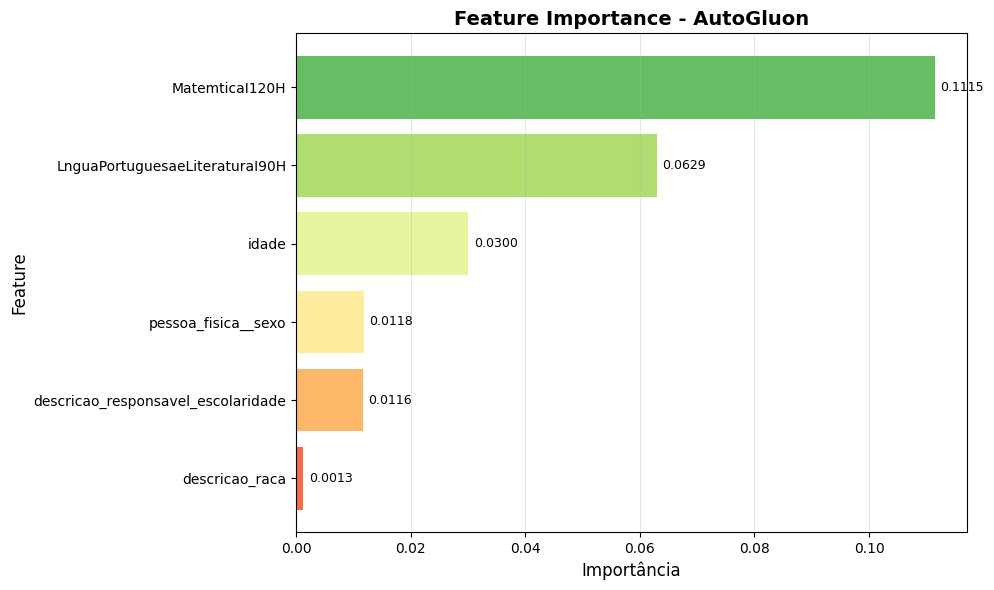

In [17]:
# Gráfico de Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))

# Ordenar por importância
fi_sorted = feature_importance.sort_values('importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(fi_sorted)))
bars = ax.barh(fi_sorted.index, fi_sorted['importance'], color=colors)

ax.set_xlabel('Importância', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - AutoGluon', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for bar, val in zip(bars, fi_sorted['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Informações sobre os Modelos Treinados

In [19]:
# Informações detalhadas sobre todos os modelos treinados
print("="*70)
print("INFORMAÇÕES DETALHADAS DOS MODELOS")
print("="*70)

# Sumário do fit
fit_summary = predictor.fit_summary()

# Informações sobre o melhor modelo
print(f"\n🏆 Melhor Modelo: {predictor.model_best}")
print(f"\nModelos treinados: {predictor.model_names()}")

INFORMAÇÕES DETALHADAS DOS MODELOS
*** Summary of fit() ***
Estimated performance of each model:
                      model  score_val eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0       WeightedEnsemble_L3   0.898931     roc_auc       0.676013  25.873132                0.000609           0.216170            3       True         24
1     ExtraTreesGini_BAG_L2   0.895644     roc_auc       0.641752  23.242827                0.100372           0.281767            2       True         18
2       WeightedEnsemble_L2   0.890154     roc_auc       0.102245  18.547178                0.000747           0.142174            2       True         12
3         LightGBMXT_BAG_L2   0.887298     roc_auc       0.559453  24.578701                0.018072           1.617640            2       True         13
4     ExtraTreesEntr_BAG_L2   0.887198     roc_auc       0.641624  23.212521                0.100243           0.251461         

/Users/tmedeirosb/Desktop/DEV/TSI/venv/lib/python3.12/site-packages/autogluon/core/utils/plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


## Salvar e Carregar o Modelo

O AutoGluon salva automaticamente os modelos durante o treinamento. Podemos também carregar o predictor salvo para fazer novas predições.

In [ ]:
# O modelo já foi salvo automaticamente no diretório 'AutogluonModels'
# Vamos verificar o caminho do modelo salvo
print(f"Modelo salvo em: {predictor.path}")
print("\nPara carregar o modelo posteriormente, use:")
print(f"predictor = TabularPredictor.load('{predictor.path}')")

In [21]:
# Carregar o modelo salvo (simulando um novo ambiente)
predictor_carregado = TabularPredictor.load('AutogluonModels')
print("Modelo carregado com sucesso!")
print(f"Melhor modelo: {predictor_carregado.model_best}")

Modelo carregado com sucesso!
Melhor modelo: WeightedEnsemble_L3


## Predição com Dados Fictícios usando o Modelo Carregado

In [22]:
# Criar dados fictícios para teste de predição
# Usar as mesmas colunas e categorias do dataset original

# Extrair categorias únicas das variáveis categóricas
escolaridade_cats = df_sel['descricao_responsavel_escolaridade'].unique().tolist()
raca_cats = df_sel['descricao_raca'].unique().tolist()
sexo_cats = df_sel['pessoa_fisica__sexo'].unique().tolist()

print("Categorias disponíveis:")
print(f"Escolaridade: {escolaridade_cats}")
print(f"Raça: {raca_cats}")
print(f"Sexo: {sexo_cats}")

# Criar DataFrame com dados fictícios
dados_ficticios = pd.DataFrame({
    'LnguaPortuguesaeLiteraturaI90H': [7.5, 4.2, 9.0, 5.5, 8.0],
    'MatemticaI120H': [6.8, 3.5, 8.5, 6.0, 7.2],
    'descricao_responsavel_escolaridade': [escolaridade_cats[0], escolaridade_cats[1] if len(escolaridade_cats) > 1 else escolaridade_cats[0], 
                                            escolaridade_cats[0], escolaridade_cats[2] if len(escolaridade_cats) > 2 else escolaridade_cats[0],
                                            escolaridade_cats[0]],
    'idade': [18, 22, 19, 25, 20],
    'descricao_raca': [raca_cats[0], raca_cats[1] if len(raca_cats) > 1 else raca_cats[0], 
                       raca_cats[0], raca_cats[2] if len(raca_cats) > 2 else raca_cats[0],
                       raca_cats[0]],
    'pessoa_fisica__sexo': [sexo_cats[0], sexo_cats[1] if len(sexo_cats) > 1 else sexo_cats[0], 
                            sexo_cats[0], sexo_cats[1] if len(sexo_cats) > 1 else sexo_cats[0],
                            sexo_cats[0]]
})

print("\nDados fictícios para predição:")
display(dados_ficticios)

Categorias disponíveis:
Escolaridade: ['Ensino fundamental incompleto', 'Ensino médio completo', 'Alfabetizado', 'Pós graduação completo', 'Ensino superior completo', 'Ensino médio incompleto', 'Ensino fundamental completo', 'Não estudou', 'Ensino superior incompleto', 'Pós graduação incompleto', 'Não conhece']
Raça: ['Branca', 'Parda', 'Preta', 'Amarela', 'Não declarado', 'Indígena']
Sexo: ['F', 'M']

Dados fictícios para predição:


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo
0,7.5,6.8,Ensino fundamental incompleto,18,Branca,F
1,4.2,3.5,Ensino médio completo,22,Parda,M
2,9.0,8.5,Ensino fundamental incompleto,19,Branca,F
3,5.5,6.0,Alfabetizado,25,Preta,M
4,8.0,7.2,Ensino fundamental incompleto,20,Branca,F


In [23]:
# Fazer predições com o modelo carregado
predicoes_ficticias = predictor_carregado.predict(dados_ficticios)
proba_ficticias = predictor_carregado.predict_proba(dados_ficticios)

print("="*70)
print("PREDIÇÕES COM DADOS FICTÍCIOS")
print("="*70)

# Criar DataFrame com resultados
resultados = dados_ficticios.copy()
resultados['predicao'] = predicoes_ficticias.values
resultados['prob_evasao'] = proba_ficticias[1].values

display(resultados)

# Interpretação dos resultados
print("\nInterpretação das predições:")
print("-" * 50)
for i, (pred, prob) in enumerate(zip(predicoes_ficticias, proba_ficticias[1])):
    status = "EVASÃO" if pred == 1 else "PERMANÊNCIA"
    print(f"Aluno {i+1}: {status} (probabilidade de evasão: {prob:.2%})")

PREDIÇÕES COM DADOS FICTÍCIOS


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo,predicao,prob_evasao
0,7.5,6.8,Ensino fundamental incompleto,18,Branca,F,1,0.777849
1,4.2,3.5,Ensino médio completo,22,Parda,M,1,0.789993
2,9.0,8.5,Ensino fundamental incompleto,19,Branca,F,1,0.745382
3,5.5,6.0,Alfabetizado,25,Preta,M,1,0.760338
4,8.0,7.2,Ensino fundamental incompleto,20,Branca,F,1,0.768991



Interpretação das predições:
--------------------------------------------------
Aluno 1: EVASÃO (probabilidade de evasão: 77.78%)
Aluno 2: EVASÃO (probabilidade de evasão: 79.00%)
Aluno 3: EVASÃO (probabilidade de evasão: 74.54%)
Aluno 4: EVASÃO (probabilidade de evasão: 76.03%)
Aluno 5: EVASÃO (probabilidade de evasão: 76.90%)


## Conclusão

Este notebook demonstrou o pipeline completo de Machine Learning usando **AutoGluon**:

1. **Carregamento e Preparação dos Dados**: Inversão das classes (0↔1)
2. **Divisão Treino/Teste**: Split estratificado 80/20
3. **Treinamento Automático**: `TabularPredictor.fit()` treina múltiplos modelos automaticamente
4. **Leaderboard**: Comparação de todos os modelos treinados com suas métricas
5. **Visualização**: Gráficos de comparação dos modelos, Matriz de Confusão e Curva ROC
6. **Métricas Completas**: Accuracy, AUC, Precision, Recall, F1-Score e G-Mean
7. **Interpretabilidade**: Feature Importance baseada em permutação
8. **Persistência**: Salvar e carregar o predictor completo
9. **Predição**: Teste com dados fictícios usando o modelo carregado

### Vantagens do AutoGluon:
- **State-of-the-art automatizado**: Treina LightGBM, CatBoost, XGBoost, Neural Networks, etc.
- **Ensemble e Stacking**: Combina modelos automaticamente para melhor performance
- **Mínima configuração**: Apenas precisa especificar a coluna target
- **Pré-processamento automático**: Lida com dados faltantes, categóricos e numéricos
- **Desenvolvido pela AWS**: Suporte ativo e documentação extensa